In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go

from k_means_clustering import KMeansClustering

In [2]:
cluster_1 = np.random.randn(100, 3) + np.array([0, 0, 0])
cluster_2 = np.random.randn(100, 3) + np.array([5, 5, 5])
cluster_3 = np.random.randn(100, 3) + np.array([0, 5, 2])

X = np.vstack((cluster_1, cluster_2, cluster_3))

In [3]:
model = KMeansClustering(k=3)
model.fit(X)

labels = model.predict(X)
centroids = np.array(model.centroids)

print("Chosen k:", model.k)
print("Inertia:", model._compute_inertia(X))

Chosen k: 3
Inertia: 850.8744097094183


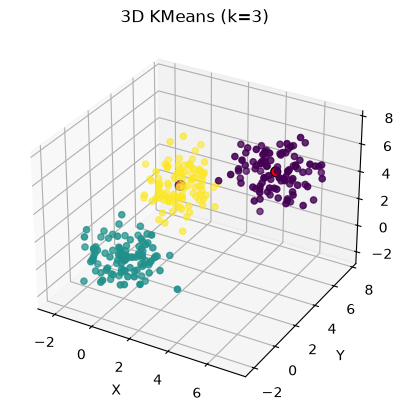

In [4]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=labels)

ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
           marker='o', s=50, c='r', edgecolors='black', linewidth=1)

ax.set_title(f"3D KMeans (k={model.k})")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

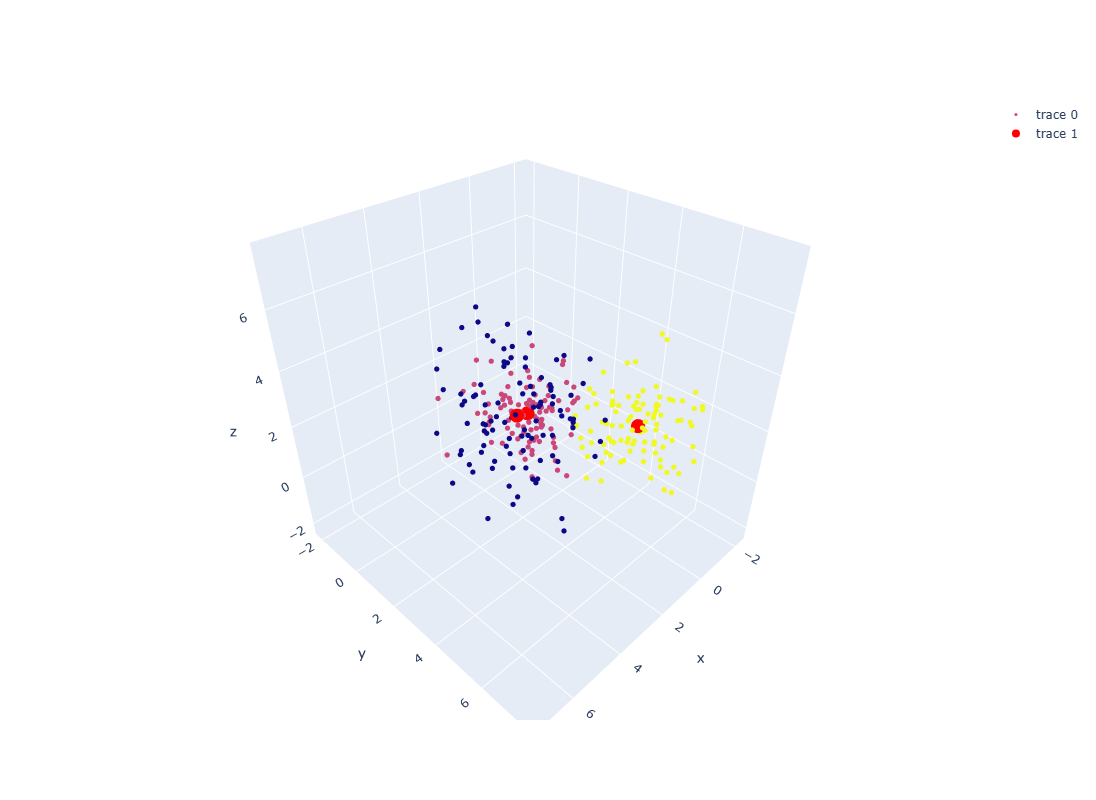

In [5]:
fig = go.Figure()
fig.update_layout(
    width=900,
    height=800
)

fig.add_trace(go.Scatter3d(
    x=X[:, 0], y=X[:, 1], z=X[:, 2],
    mode='markers',
    marker=dict(size=3, color=labels)
))

fig.add_trace(go.Scatter3d(
    x=centroids[:, 0], y=centroids[:, 1], z=centroids[:, 2],
    mode='markers',
    marker=dict(size=8, color='red', symbol='circle')
))

fig.show()